# Challenge: Edit MNIST challenge images to be correctly predicted

Goal: Edit the images placed in `data/MNIST/challenge` so that the provided model predicts the correct label while keeping more than 60% of the original pixels unchanged.

Description: You are given a pre-trained `SmallCNN` model and a small set of challenge images. Your task is to minimally modify these images so the model classifies them correctly. This exercise encourages you to: 
- Explore the sample dataset in `data/MNIST/sample` to understand variation and typical inputs.
- Use explainable AI (XAI) techniques (saliency maps, Grad-CAM, Integrated Gradients, occlusion, etc.) to discover what parts of the image the model relies on.
- Propose minimal edits (pixel changes, small masks, subtle color shifts) that change model prediction while preserving at least 60% of the original pixels.

Deliverables: For each edited image, save the modified image to `data/MNIST/challenge/edited/` alongside a short report (less than 2 pages) describing the XAI insights you used and the percentage of pixels preserved. For ease of use, you have the images already in that folder and you can directly work on them. You are allowed to use any external program you want to modify the image (i.e., paint, photoshop, figma, ...).

The practice can be done by more than 1 person. Final grade would depend on the number of images correctly edited (n_images_correct) with their corresponding report and number of persons working together (n_persons) following the next formula:
$$grade = 2,5 \times n\_images\_correct - 2,5 * (n\_persons - 1)$$


In [1]:
# Imports and device
import torch
import torch.nn as nn
from torchvision import transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from copy import deepcopy
import numpy as np
from captum.attr import IntegratedGradients
from scipy.ndimage import gaussian_filter, convolve
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

c:\Users\User\Documents\Primero\etica_y_explicabilidad\Practicas\p2-computer-vision-sofia\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [2]:
# SmallCNN definition (must match the trained model architecture)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(12*7*7, 12)
        self.fc2 = nn.Linear(12, num_classes)

    def forward(self, x):
        x = self.pool(torch.nn.functional.relu(self.conv1(x)))  # 14x14
        x = self.pool(x)                      # 7x7
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.nn.functional.relu(self.fc1(x)))
        return self.fc2(x)

# convenience transform
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

In [3]:
models_dir = Path('../models')
model_name = models_dir / 'small_cnn.pth'
model = torch.load(model_name, weights_only=False)
model.to(device) 
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=588, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=10, bias=True)
)

0_label5.png: Pred: 1, Label: 5
1_label3.png: Pred: 1, Label: 3
2_label3.png: Pred: 1, Label: 3
3_label7.png: Pred: 3, Label: 7
4_label2.png: Pred: 6, Label: 2


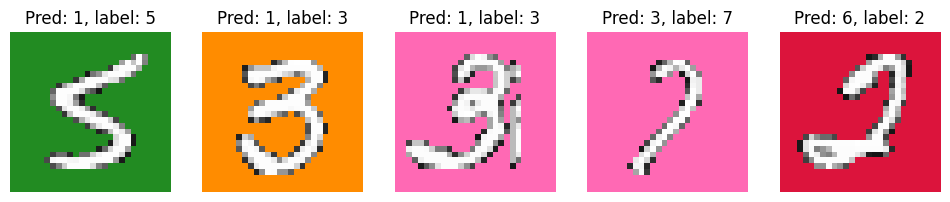

In [4]:
# Load the images in data/MNIST/challenge/ and plot them. Label of the image is the last character of the filename.
challenge_dir = Path('../data/MNIST/challenge')
image_files = list(challenge_dir.glob('*.png'))
fig, axes = plt.subplots(1, len(image_files), figsize=(12,4))
for ax, img_file in zip(axes, image_files):
    img = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()
    ax.imshow(to_pil(img.squeeze().cpu()))
    ax.set_title(f'Pred: {pred}, label: {img_file.stem[-1]}')
    ax.axis('off')
    print(f'{img_file.name}: Pred: {pred}, Label: {img_file.stem[-1]}')
plt.show()

---
### Any code you want to add, put it below this markdown cell

## Funciones auxiliares

In [5]:
def contrastive_explanation(image: torch.Tensor, model: SmallCNN, device: torch.device, true_label: int = 5, predicted_label: int = 1, n_steps: int = 50):
    """
    Explains the difference between the expected prediction and 
    the actual prediction using integrated gradients
    Args:
    - image (torch.Tensor)
    - model (SmallCNN)
    - device (torch.device)
    - true_label (int)
    - predicted_label (int)
    - n_steps (int)
    Returns:
    - attr_pred (torch.Tensor): explanation for the model prediction
    - attr_true (torch.Tensor): explanation for the actual label
    - contrastive (torch.Tensor): difference between the explanation of the true and actual prediction
    """
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)

    model.eval()
    model.to(device)
    image = image.requires_grad_(True)
    
    # Integrated Gradients para ambas clases
    ig = IntegratedGradients(model)
    
    # Atribuciones para la clase predicha
    attr_pred = ig.attribute(image, target=predicted_label, n_steps=n_steps)
    
    # Atribuciones para la clase correcta
    attr_true = ig.attribute(image, target=true_label, n_steps=n_steps)
    
    # DIFERENCIA: qué hace que prediga prediced en lugar de target
    contrastive = attr_pred - attr_true
    
    return attr_pred, attr_true, contrastive

def explain_and_visualize_integrated_gradients(image: torch.Tensor, model: SmallCNN, device: torch.device, true_label: int, predicted_label: int, threshold: int = 60, n_steps: int = 500):
    """
    Explains and visualizes the difference between the expected prediction and 
    the actual prediction using integrated gradients
    Args:
    - image (torch.Tensor)
    - model (SmallCNN)
    - device (torch.device)
    - true_label (int)
    - predicted_label (int)
    - n_steps (int)
    - threshold (int)
    Returns:
    - attr_pred_vis (np.ndarray): explanation for the model prediction
    - attr_true_vis (np.ndarray): explanation for the actual label
    - contrastive_vis (np.ndarray): difference between the explanation of the true and actual prediction
    - problematic_pixels (np.ndarray): mask with the pixels that lead the model to the wrong label
    """

    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)
    attr_pred, attr_true, contrastive = contrastive_explanation(
        image, model, device, true_label=true_label, predicted_label=predicted_label, n_steps=n_steps
    )

    # Visualizar
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Fila 1: Original y atribuciones
    axes[0, 0].imshow(to_pil(image.squeeze().cpu()))
    axes[0, 0].set_title("Imagen Original")
    axes[0, 0].axis('off')

    # Atribución para clase 1 (predicha)
    attr_pred_vis = attr_pred.squeeze().cpu().detach().numpy().sum(axis=0)
    im1 = axes[0, 1].imshow(attr_pred_vis, cmap='RdYlGn')
    axes[0, 1].set_title(f"Atribución para Clase {predicted_label}\n(predicción actual)")
    axes[0, 1].axis('off')
    plt.colorbar(im1, ax=axes[0, 1])

    # Atribución para clase 5 (correcta)
    attr_true_vis = attr_true.squeeze().cpu().detach().numpy().sum(axis=0)
    im2 = axes[0, 2].imshow(attr_true_vis, cmap='RdYlGn')
    axes[0, 2].set_title(f"Atribución para Clase {true_label}\n(target)")
    axes[0, 2].axis('off')
    plt.colorbar(im2, ax=axes[0, 2])

    # Fila 2: Análisis contrastivo
    axes[1, 0].imshow(to_pil(image.squeeze().cpu()))
    axes[1, 0].set_title("Imagen Original")
    axes[1, 0].axis('off')

    # Diferencia (contrastivo)
    contrast_vis = contrastive.squeeze().cpu().detach().numpy().sum(axis=0)
    im3 = axes[1, 1].imshow(contrast_vis, cmap='RdBu_r')
    axes[1, 1].set_title(f"CONTRASTIVO\nRojo→empuja a {predicted_label} \nAzul→empuja a {true_label}")
    axes[1, 1].axis('off')
    plt.colorbar(im3, ax=axes[1, 1])

    # Overlay
    contrast_abs = np.abs(contrast_vis)
    contrast_norm = (contrast_abs - contrast_abs.min()) / (contrast_abs.max() - contrast_abs.min())
    overlay = to_pil(image.squeeze().cpu())
    overlay_arr = np.array(overlay).astype(float)
    # Resaltar píxeles problemáticos en rojo
    overlay_arr[:, :, 0] += contrast_norm * 100 * (contrast_vis > 0)
    overlay_arr = np.clip(overlay_arr, 0, 255).astype(np.uint8)
    axes[1, 2].imshow(overlay_arr)
    axes[1, 2].set_title(f"Píxeles que causan\nconfusión hacia {predicted_label}")
    axes[1, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # Crear máscara de píxeles a modificar
    threshold = np.percentile(np.abs(contrast_vis), threshold)
    problematic_pixels = (contrast_vis > threshold)  # Píxeles que empujan fuertemente hacia la clase incorrecta

    print(f"Píxeles problemáticos: {problematic_pixels.sum()} de 784 ({100*problematic_pixels.sum()/784:.1f}%)")

    return attr_pred_vis, attr_true_vis, contrast_vis, problematic_pixels

In [6]:
def modify_image_based_on_mask(image: torch.Tensor, contrast_vis: np.ndarray, img_file: str, incorrect_threshold: int = 70, correct_threshold: int = 10):
    """
    Modify and image based on a contrast_vis tensor. This tensor contains the difference between the explanations
    of the correct label and the predicted label (high values indicate that the pixel leads the model in a right 
    direction). It saves the image in "edited" folder with the right name
    Args:
    - image (torch.tensor)
    - contrast_vis (np.ndarray)
    - img_file (str): dir to the image
    - incorrect_threshold (int): below which percentaje of pixels are the "wrong" pixels
    - correct_threshold (int): above which percentaje of pixels are the "right" pixels
    Returns:
    - img_np (np.ndarray): modified iamage
    """
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)
    image_modified = image.clone()
    img = image_modified[0].cpu()
    img = img.to("cpu").detach().numpy()
    
    contrast = torch.tensor(contrast_vis)
    contrast = contrast.float()

    # Máscaras
    mask_to_incorrect = (contrast > np.percentile(contrast.cpu(), incorrect_threshold))
    mask_to_correct = (contrast < np.percentile(contrast.cpu(), correct_threshold))

    # Aplicar transformaciones
    for c in range(3):
        channel = img[c]
        smoothed = gaussian_filter(channel, sigma=1)

        # Castigar píxeles que empujan a incorrect → los suavizamos
        img[c][mask_to_incorrect] = 0.5 * channel[mask_to_incorrect] + 0.5 * smoothed[mask_to_incorrect]

        # Premiar píxeles que empujan a 3 → mask_to_correct aclaramos (los hacemos más brillantes)
        img[c][mask_to_correct] = np.clip(channel[mask_to_correct] * 1.2, 0, 1)

    # Mostrar resultados
    img_np = img.transpose(1, 2, 0)
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(to_pil(image.squeeze().cpu()))
    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_np)
    plt.title("Imagen Modificada")
    plt.axis('off')
    plt.show()

    print(img_file.name)
    print(challenge_dir / 'edited' / img_file.name)
    edited_dir = challenge_dir / 'edited'
    edited_dir.mkdir(parents=True, exist_ok=True)

    # img_np ya está [H,W,C], valores float [0,1]
    to_pil(img_np).save(edited_dir / img_file.name)
    print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

    return img_np

In [7]:
def find_best_prototype(model: SmallCNN, device: torch.device, target_class: int = 5, data_dir: str = '../data/MNIST/sample'):
    """
    Finds the image with that label in the sample dataset 
    where the probability of classifying the right label is 
    the highest
    Args:
    - model (SmallCNN)
    - device (torch.deviec)
    - targe_class (int)
    - data_dir (str)
    Returns:
    - best_image (torch.Tensor)
    - best_path (str)
    - best_score (float)
    """
    
    sample_dir = Path('../data/MNIST/sample')
    best_score = -float('inf')
    best_image = None
    best_path = None
    
    model.eval()
    
    # Buscar todas las imágenes de la clase target
    pattern = f"*label{target_class}.png"
    target_images = list(sample_dir.glob(pattern))

    print(f"Analizando {len(target_images)} imágenes de clase {target_class}...")
    
    with torch.no_grad():
        for img_path in target_images:
            img = to_tensor(Image.open(img_path)).unsqueeze(0).to(device)
            output = model(img)
            
            # Confianza en la clase correcta
            probs = torch.softmax(output, dim=1)
            score = probs[0, target_class].item()
            
            if score > best_score:
                best_score = score
                best_image = img
                best_path = img_path
    
    print(f"\nMejor ejemplar encontrado: {best_path.name}")
    print(f"Confianza: {best_score:.4f}")
    
    return best_image, best_path, best_score

In [8]:
def plot_square(top: int, left: int, height: int, width: int, image: torch.Tensor, color: str = "white"):
    """
    Plots a square above an image starting in the top-left pixel with the indicated
    height and width. The square can be white or black (if the color input != "white")
    Args:
    - top (int)
    - left (int)
    - height (int)
    - width (int)
    - image (torch.Tensor)
    - color (str): color of the square. It can be "white". Other inputs will result in a black square
    Returns:
    - img (torch.Tensor): modified image
    """
    image_modified = image.clone()
    if len(image_modified.size()) > 3:
        img = image_modified[0]
    else:
        img = image_modified
    if color == "white":
        # Aplicar cuadrado blanco
        img[:, top:top+height, left:left+width] = 1
    else:
        img[:, top:top+height, left:left+width] = 0
    # Mostrar la imagen modificada
    plt.figure(figsize=(5,5))
    plt.imshow(to_pil(img))
    plt.title("Imagen con Cuadro")
    plt.axis('off')
    plt.show()

    return img


In [9]:
def create_combined_mask(occlusion_map: np.ndarray, saliency: np.ndarray, activation_map: np.ndarray, activation_map_1: np.ndarray, top_percent: int = 20):
    """
    Creates a mask combining various explanations resutls.
    The mask is: 0.4 * cam_norm + 0.4*cam_norm_1 + 0.1*occ_norm + 0.1*sal_norm
    keeping the "top_percent" pixels
    Args:
    - occlusion_map (np.ndarray)
    - saliency (np.ndarray)
    - activation_map (np.ndarray)
    - activation_map_1 (np.ndarray)
    - top_percent (int)
    Returns:
    - mask (np.ndarray)
    """
    def normalize(arr):
        arr_min, arr_max = arr.min(), arr.max()
        if arr_max > arr_min:
            return (arr - arr_min) / (arr_max - arr_min)
        return arr

    h, w = 28, 28
    top_percent = top_percent
    occ_norm = normalize(occlusion_map.squeeze()).cpu()
    sal_norm = normalize(saliency.squeeze()).cpu()
    cam_norm = normalize(activation_map[0].cpu())
    cam_norm_1 = normalize(activation_map_1[0].cpu())
    # Resize todo a mismo tamaño (28x28)

    # 3. Combinar mapas (dar más peso a GradCAM y Saliency)
    combined = 0.4 * cam_norm + 0.4*cam_norm_1 + 0.1*occ_norm + 0.1*sal_norm

    # 4. Seleccionar top X% de píxeles más problemáticos
    threshold = np.percentile(combined.detach().numpy(), 100 - top_percent)
    mask = combined > threshold

    print(f"Píxeles a modificar: {mask.sum()} de {h*w} ({100*mask.sum()/(h*w):.1f}%)")

    return mask


In [10]:
def modify_image_based_on_mask_with_mode(
    image: torch.Tensor, contrast_vis: np.ndarray, img_file: str, 
    incorrect_threshold: int = 70, correct_threshold: int = 10,
    mode: str = 'smooth', intensity: float =0.5
):
    """
    Modify an image based on a contrast_vis mask type (where some pixels lead to the wrong
    prediction and some to the right).. It saves the image in "edited" folder with the right name
    Args:
    - image (torch.tensor)
    - contrast_vis (np.ndarray)
    - img_file (str): dir to the image
    - incorrect_threshold (int): below which percentaje of pixels are the "wrong" pixels
    - correct_threshold (int): above which percentaje of pixels are the "right" pixels
    - mode (str): smooth, black, white, random_color, brighten, darken
    - intensity (float): how much to darken or whiten the image depending on the mode
    Returns:
    - img_np (np.ndarray): modified iamage

    
    """
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)
    
    image_modified = image.clone()
    img = image_modified[0].cpu().numpy()
    
    contrast = torch.tensor(contrast_vis).float()
    
    mask_to_incorrect = (contrast > np.percentile(contrast.cpu(), incorrect_threshold))
    mask_to_correct = (contrast < np.percentile(contrast.cpu(), correct_threshold))

    H, W = mask_to_incorrect.shape
    for c in range(3):
        channel = img[c]
        smoothed = gaussian_filter(channel, sigma=1)
        
        if mode == 'smooth':
            # Suavizar los píxeles incorrectos
            channel[mask_to_incorrect] = 0.5 * channel[mask_to_incorrect] + 0.5 * smoothed[mask_to_incorrect]
            # Aclarar los píxeles correctos
            channel[mask_to_correct] = np.clip(channel[mask_to_correct] * 1.2, 0, 1)
        
        elif mode == 'black':
            channel[mask_to_incorrect] = 0.0
        
        elif mode == "white":
            channel[mask_to_correct] = 255
    
        elif mode == 'random_color':
            channel[mask_to_incorrect] = np.random.rand(np.sum(mask_to_incorrect))
        
        elif mode == 'brighten':
            channel[mask_to_correct] = np.clip(channel[mask_to_correct] * intensity, 0, 1)
        
        elif mode == "darken":
            channel[mask_to_correct] = np.clip(channel[mask_to_correct] * intensity, 0, 1)
        img[c] = channel

    # Mostrar resultados
    img_np = img.transpose(1, 2, 0)
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(Image.fromarray((image.squeeze().cpu().numpy().transpose(1,2,0)*255).astype(np.uint8)))
    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_np)
    plt.title(f"Imagen Modificada ({mode})")
    plt.axis('off')
    plt.show()
    
    # Guardar imagen
    challenge_dir = Path('../data/MNIST/challenge')
    edited_dir = challenge_dir / 'edited'
    edited_dir.mkdir(parents=True, exist_ok=True)
    
    img_uint8 = (img_np * 255).astype(np.uint8)
    Image.fromarray(img_uint8).save(edited_dir / img_file.name)
    print(f"Imagen guardada en: {edited_dir / img_file.name}")

    return img_np


In [11]:
def modify_image_with_bool_mask(
    image: torch.Tensor, mask: np.ndarray, img_file: str,
    mode: str = 'smooth', intensity: float = 0.5,
    save_dir: str='../data/MNIST/challenge'
):
    """
    Apply modifications to an image only where the mask is True

    Args
    - image (torch.tensor)
    - contrast_vis (np.ndarray)
    - img_file (str): dir to the image
    - mode (str): smooth, black, white, random_color, brighten, darken
    - intensity (float): how much to darken or whiten the image depending on the mode
    Returns:
    - img_np (np.ndarray): modified iamage

    """
    torch.manual_seed(0)
    np.random.seed(0)
    random.seed(0)
    
    image_np = image[0].cpu().numpy().copy()  # (3, H, W)
    H, W = image_np.shape[1:]
    
    # Convertir máscara a numpy si viene como tensor
    if isinstance(mask, torch.Tensor):
        mask_np = mask.squeeze().cpu().numpy().astype(bool)
    else:
        mask_np = mask.astype(bool)
    
    # Asegurar tamaño correcto
    assert mask_np.shape == (H, W), f"Dimensiones incorrectas: {mask_np.shape}, se esperaba ({H}, {W})"
    
    # Aplicar cambios por canal
    for c in range(3):
        channel = image_np[c]
        smoothed = gaussian_filter(channel, sigma=1)
        
        if mode == 'smooth':
            channel[mask_np] = 0.5 * channel[mask_np] + 0.5 * smoothed[mask_np]
        
        elif mode == 'black':
            channel[mask_np] = 0.0
        
        elif mode == 'white':
            channel[mask_np] = 1.0
        
        elif mode == 'random_color':
            channel[mask_np] = np.random.rand(np.sum(mask_np))
        
        elif mode == 'brighten':
            channel[mask_np] = np.clip(channel[mask_np] * (1 + intensity), 0, 1)
        
        elif mode == 'darken':
            channel[mask_np] = np.clip(channel[mask_np] * (1 - intensity), 0, 1)
        
        else:
            raise ValueError(f"Modo '{mode}' no reconocido.")
        
        image_np[c] = channel

    # Convertir a formato visualizable
    img_np = image_np.transpose(1, 2, 0)
    
    # Mostrar resultados
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(image.squeeze().permute(1, 2, 0).cpu())
    plt.title("Imagen Original")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_np)
    plt.title(f"Imagen Modificada ({mode})")
    plt.axis('off')
    plt.show()

    # Guardar imagen
    edited_dir = challenge_dir / 'edited'
    edited_dir = Path(edited_dir)
    edited_dir.mkdir(parents=True, exist_ok=True)

    img_uint8 = (img_np * 255).astype(np.uint8)
    Image.fromarray(img_uint8).save(edited_dir / Path(img_file).name)
    print(f"Imagen guardada en: {edited_dir / Path(img_file).name}")

    return torch.tensor(img_np).permute(2, 0, 1).unsqueeze(0)


In [12]:
def blend_images(img1: torch.Tensor, img2: torch.Tensor, ratio: float = 0.4, mode: str = 'left', mask=None):
    """
    Puts ratio% of img1 in img2
    
    Args:
    - img1, img2 (torch.tensor)
    - ratio: percentaje of img1 to use
    - mode: 'left', 'right', 'top', 'bottom', 'random', 'checkerboard', 'mask'
    -  mask: mask for mode "mask"
    Returns:
        Imagen mezclada
    """

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)
    result = img2.clone()
    C, H, W = img1.shape
    
    if mode == 'left':
        cut = int(W * ratio)
        result[:, :, :cut] = img1[:, :, :cut]
    
    elif mode == 'right':
        cut = int(W * (1 - ratio))
        result[:, :, cut:] = img1[:, :, cut:]
    
    elif mode == 'top':
        cut = int(H * ratio)
        result[:, :cut, :] = img1[:, :cut, :]
    
    elif mode == 'bottom':
        cut = int(H * (1 - ratio))
        result[:, cut:, :] = img1[:, cut:, :]
    
    elif mode == 'center':
        # Región central
        h_start = int(H * (1 - ratio) / 2)
        h_end = int(H * (1 + ratio) / 2)
        w_start = int(W * (1 - ratio) / 2)
        w_end = int(W * (1 + ratio) / 2)
        result[:, h_start:h_end, w_start:w_end] = img1[:, h_start:h_end, w_start:w_end]
    
    elif mode == 'random':
        # Píxeles aleatorios
        mask = torch.rand(H, W) < ratio
        result[:, mask] = img1[:, mask]
    
    elif mode == 'checkerboard':
        # Patrón de tablero
        mask = torch.zeros(H, W, dtype=torch.bool)
        mask[::2, ::2] = True
        mask[1::2, 1::2] = True
        # Ajustar para ratio aproximado
        if ratio < 0.5:
            mask = mask & (torch.rand(H, W) < ratio * 2)
        result[:, mask] = img1[:, mask]
    
    elif mode == "mask":
        
        
        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask)

        mask = mask.to(device)
        
        if mask.dtype == torch.bool:
            mask = mask.float()
        
        # Asegurar que la máscara esté en [0, 1]
        if mask.max() > 1.0:
            mask = mask / mask.max()
            
        if mask.dim() == 2:
            mask = mask.unsqueeze(0) 
        
        mask = mask.expand_as(img1)
        
        result =  mask * img1 + (1 - mask) * img2
    return result

In [13]:
def apply_sparsity_constraint(
    original_image: torch.Tensor, 
    modified_image: torch.Tensor, 
    max_change_ratio: float = 0.4, 
    method: str ='largest_diff', 
    threshold: float = 1.0/255.0
):
    """
    Limits the changes so only "max_change_ratio"% of pixels
    are changed between the original image and the modified.
    Args:
    - original_image (torch.Tensor)
    - modified_image (torch.Tensor)
    - max_change_ratio (float)
    - method (str): method to choose which pixels to mantain from the modified image
    - threshold (float)
    Returns:
    - results (torch.Tensor)
    """
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    original = original_image.to(torch.float32)
    modified = modified_image.to(torch.float32)

    # Asume forma (1, C, H, W)
    assert original.ndim == 4, "Se espera tensor con forma (1, C, H, W)"

    # Calcula diferencia absoluta promedio sobre canales
    diff = torch.abs(modified - original)
    pixel_diff = diff.mean(dim=1).squeeze(0)  # (H, W)

    # Píxeles que cambiaron significativamente
    changed_pixels = pixel_diff > threshold
    num_changed = changed_pixels.sum().item()
    total_pixels = changed_pixels.numel()
    max_pixels_to_change = int(total_pixels * max_change_ratio)

    print(f"Píxeles cambiados: {num_changed}/{total_pixels} ({100*num_changed/total_pixels:.1f}%)")
    print(f"Límite permitido: {max_pixels_to_change}/{total_pixels} ({100*max_change_ratio:.1f}%)")

    if num_changed <= max_pixels_to_change:
        print("No es necesario aplicar restricción de esparsidad")
        result = modified.clone()
    else:
        # Necesitamos reducir cambios
        flat_diff = pixel_diff.flatten()

        if method == 'largest_diff':
            # Mantiene los píxeles con mayor diferencia
            _, top_indices = torch.topk(flat_diff, max_pixels_to_change)
        elif method == 'random':
            changed_indices = torch.where(changed_pixels.flatten())[0]
            perm = torch.randperm(len(changed_indices))
            top_indices = changed_indices[perm[:max_pixels_to_change]]
        else:
            raise ValueError("Método no reconocido: usa 'largest_diff' o 'random'")

        # Máscara de píxeles a mantener modificados
        keep_mask = torch.zeros_like(flat_diff, dtype=torch.bool)
        keep_mask[top_indices] = True
        keep_mask = keep_mask.reshape(pixel_diff.shape)  # (H, W)

        # Expande a todos los canales
        keep_mask = keep_mask.unsqueeze(0).expand_as(modified.squeeze(0))  # (C, H, W)
        keep_mask = keep_mask.unsqueeze(0)  # (1, C, H, W)

        # Aplica la máscara
        result = torch.where(keep_mask, modified, original)

    # Cuantiza a 8 bits
    result_quantized = torch.round(result * 255) / 255

    # Verificación: porcentaje real de píxeles distintos
    res_np = (result_quantized.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    orig_np = (original.squeeze(0).permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
    diff_mask = np.any(res_np != orig_np, axis=-1)
    actual_percentage = diff_mask.mean() * 100

    print(f"Porcentaje REAL de píxeles cambiados (verificado): {actual_percentage:.2f}%")

    return result_quantized.cpu()

In [14]:
def extract_top_saliency_pixels(saliency_map, top_ratio=0.1, normalize=True):
    """
    Extract a binary mask containing the top X% most influential pixels according to the saliency map.

    Args:
    - saliency_map (torch.Tensor): Saliency map of shape (1, 1, H, W) or (1, C, H, W).
    - top_ratio (float): Proportion of pixels to keep (0.1 = top 10%).
    - normalize (bool): If True, normalize the map before selecting.

    Returns:
    - top_mask (torch.Tensor): Boolean mask (1, 1, H, W) with True for the most important pixels.
    - threshold_value (float): Saliency threshold value used.
    """
    # Asegurar tensor sin gradientes y en float
    saliency = saliency_map.detach().abs().float()

    # Promediar sobre canales si los hay
    if saliency.dim() == 4:
        saliency = saliency.mean(dim=1, keepdim=True)  # (1, 1, H, W)
    elif saliency.dim() == 3:
        saliency = saliency.mean(dim=0, keepdim=True).unsqueeze(0)
    else:
        raise ValueError("El mapa de saliencia debe tener forma (1, C, H, W) o (C, H, W).")

    # Normaliza entre 0 y 1 si se desea
    if normalize:
        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    # Define el umbral para conservar el top X%
    flat = saliency.flatten()
    k = int(len(flat) * top_ratio)
    if k < 1:
        raise ValueError("top_ratio demasiado pequeño: menos de 1 píxel seleccionado.")

    threshold_value = torch.topk(flat, k).values.min()

    # Crea máscara binaria (True donde la saliencia ≥ umbral)
    top_mask = (saliency >= threshold_value)

    return top_mask, threshold_value


## Imagen 1

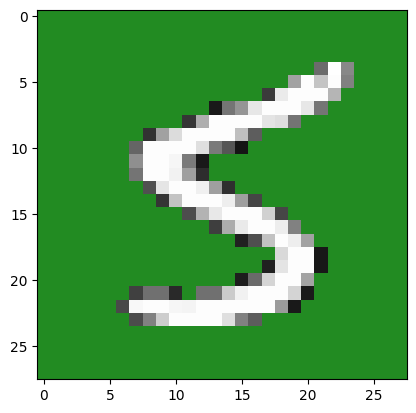

In [15]:
img_file = image_files[0]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.show()

### Explicabilidad

c:\Users\User\Documents\Primero\etica_y_explicabilidad\Practicas\p2-computer-vision-sofia\src\occlusion.py:76: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(outputs)


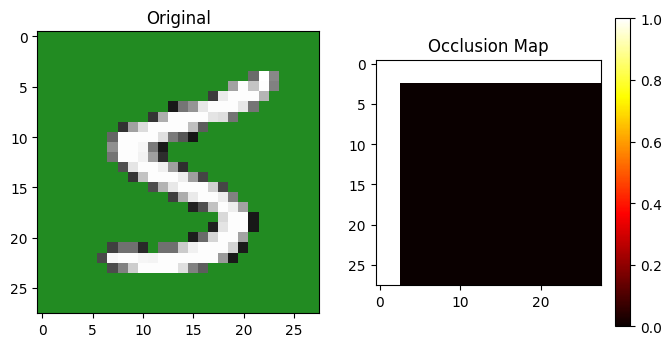

In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.occlusion import Occlusion

model.eval()
model = model.to(device)
occlusion = Occlusion(model, mask_size=4)
with torch.no_grad():
    occlusion_map = occlusion.explain(image.to(device))  

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(occlusion_map.squeeze().cpu(), cmap='hot')
plt.title("Occlusion Map")
plt.colorbar()
plt.show()


c:\Users\User\Documents\Primero\etica_y_explicabilidad\Practicas\p2-computer-vision-sofia\.venv\lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


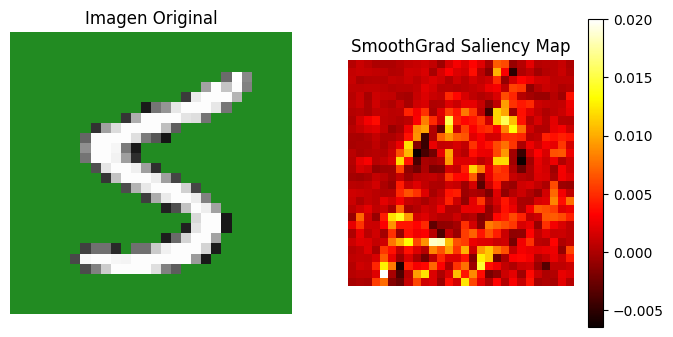

In [17]:
from src.saliency_maps import SmoothGradSaliencyMap
torch.manual_seed(42)

smoothgrad = SmoothGradSaliencyMap()

noise_level = 0.2
sample_size = 50      

model_saliency = deepcopy(model)
model_saliency.eval()


saliency = smoothgrad.explain(
    inputs=image.to(next(model_saliency.parameters()).device),
    model=model_saliency,
    noise_level=noise_level,
    sample_size=sample_size
)


plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().permute(1, 2, 0).cpu())
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency.cpu().detach().numpy().squeeze(), cmap='hot')
plt.title("SmoothGrad Saliency Map")
plt.axis('off')
plt.colorbar()
plt.show()


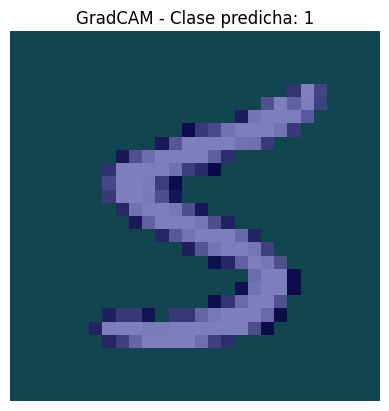

In [18]:
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt

model_cam = deepcopy(model)
model_cam.eval()
cam_extractor = GradCAM(model_cam, target_layer="conv1")

# Forward pass
output = model_cam(image)
pred_class = output.argmax(dim=1).item()

# Extrae Grad-CAM para la clase predicha
activation_map = cam_extractor(pred_class, output)

# Convertir la imagen y el mapa
result = overlay_mask(
    to_pil(image.squeeze().cpu()),
    to_pil(activation_map[0]),
    alpha=0.5
)

plt.imshow(result)
plt.title(f"GradCAM - Clase predicha: {pred_class}")
plt.axis('off')
plt.show()


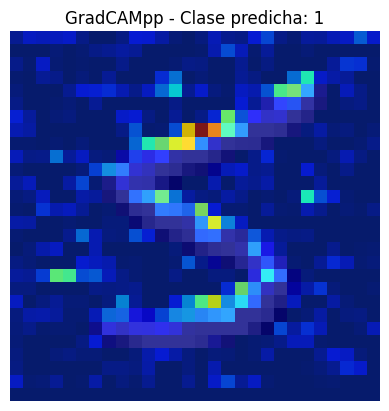

In [19]:
from torchcam.methods import SmoothGradCAMpp
from torchvision.transforms.functional import normalize, resize, to_pil_image
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt

torch.manual_seed(0)

model_cam = deepcopy(model)
model_cam.eval()
cam_extractor = SmoothGradCAMpp(model_cam, target_layer="conv1")

# Forward pass
output = model_cam(image)
pred_class = output.argmax(dim=1).item()

# Extrae Grad-CAM para la clase predicha
activation_map_1 = cam_extractor(1, output)

# Convertir la imagen y el mapa
result = overlay_mask(
    to_pil(image.squeeze().cpu()),
    to_pil_image(activation_map_1[0], mode='F'),
    alpha=0.2
)

plt.imshow(result)
plt.title(f"GradCAMpp - Clase predicha: {pred_class}")
plt.axis('off')
plt.show()


Comparo con una que predice 5

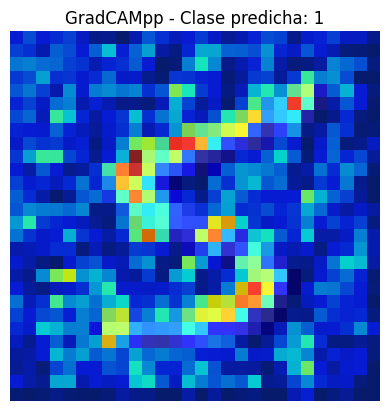

In [20]:
from torchcam.methods import SmoothGradCAMpp
from torchvision.transforms.functional import normalize, resize, to_pil_image
from torchcam.utils import overlay_mask
import matplotlib.pyplot as plt

torch.manual_seed(0)

model_cam = deepcopy(model)
model_cam.eval()
cam_extractor = SmoothGradCAMpp(model_cam, target_layer="conv1")

# Forward pass
output = model_cam(image)
pred_class = output.argmax(dim=1).item()

# Extrae Grad-CAM para la clase predicha
activation_map = cam_extractor(5, output)

# Convertir la imagen y el mapa
result = overlay_mask(
    to_pil(image.squeeze().cpu()),
    to_pil_image(activation_map[0], mode='F'),
    alpha=0.2
)

plt.imshow(result)
plt.title(f"GradCAMpp - Clase predicha: {pred_class}")
plt.axis('off')
plt.show()


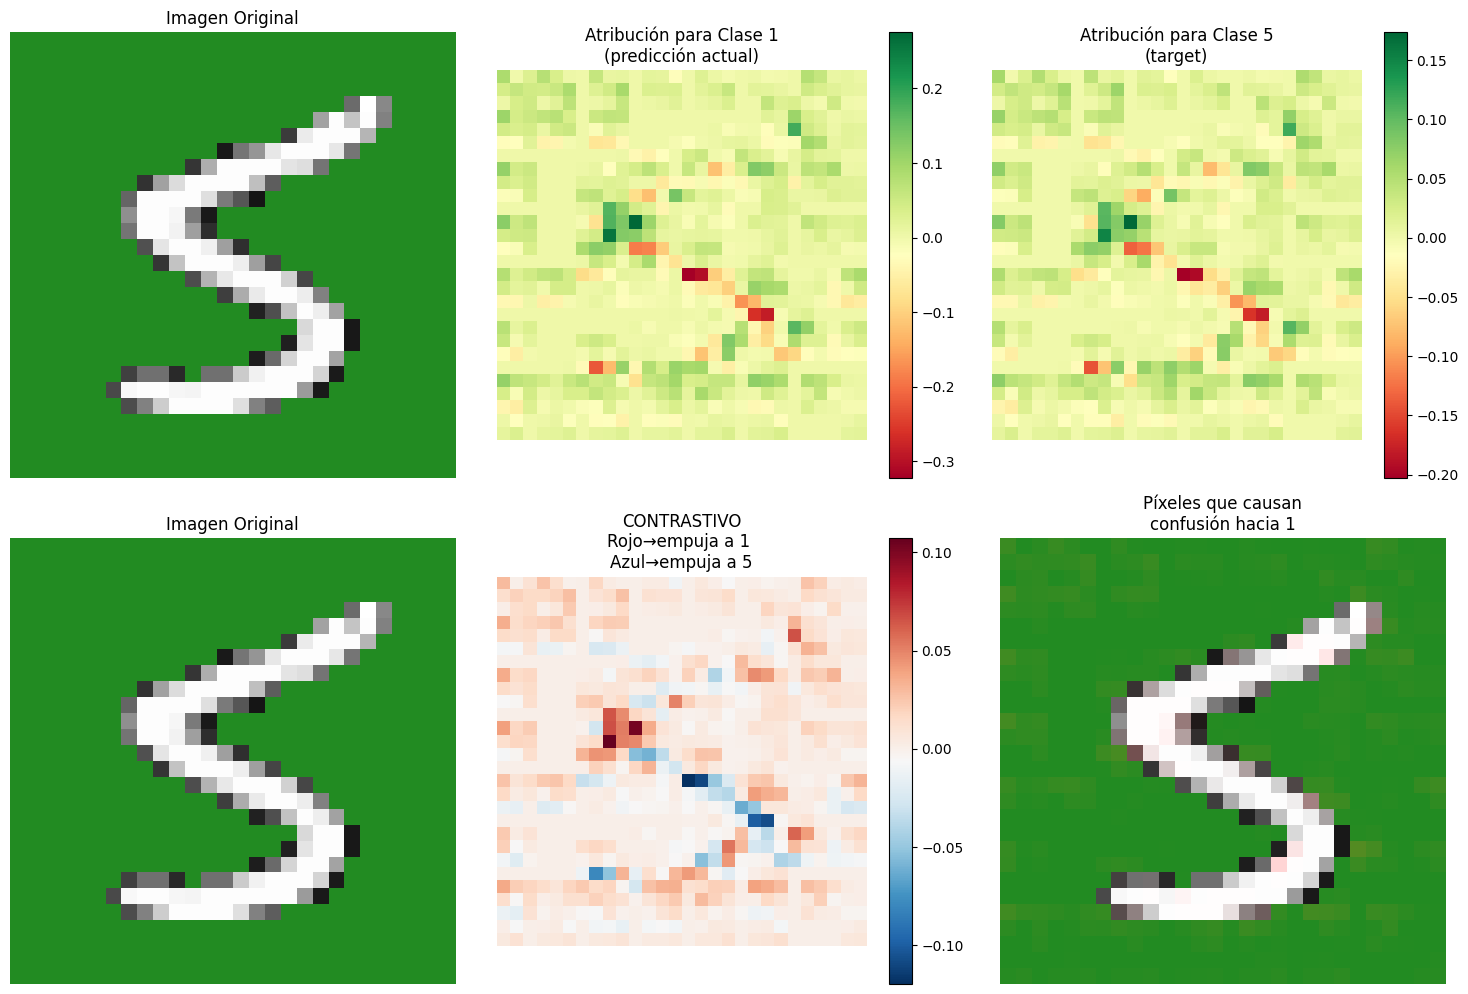

Píxeles problemáticos: 307 de 784 (39.2%)


In [21]:
model_integrated = deepcopy(model)
model_integrated.eval()
attr_pred, attr_true, contrastive, problematic_pixels = explain_and_visualize_integrated_gradients(image, model_integrated, device, true_label=5, predicted_label=1, n_steps=500, threshold=45)


Intento ver cómo tendría que mover la imagen teniendo también en cuenta qué imagenes realmente clasifica como 5

Analizando 892 imágenes de clase 5...

Mejor ejemplar encontrado: 09729_idx9729_label5.png
Confianza: 0.2234


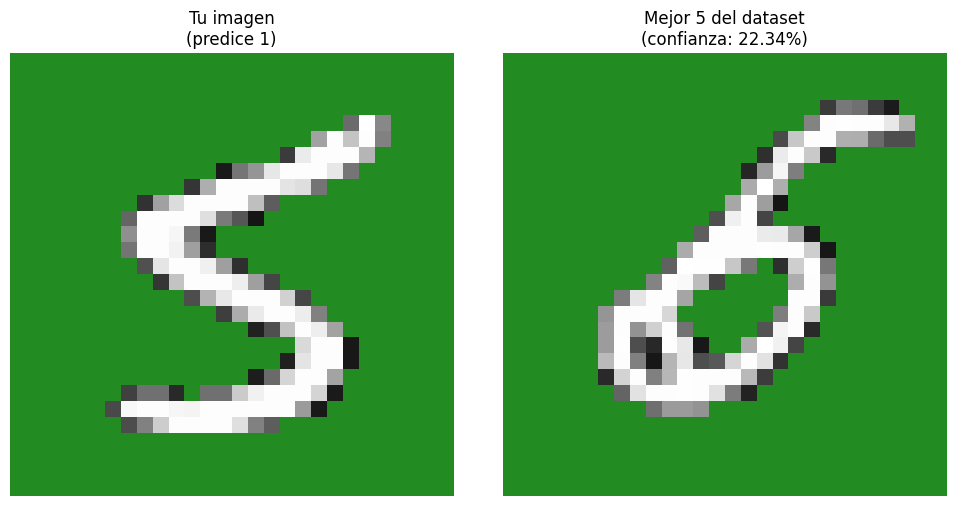

In [22]:
# Buscar mejor 5
best_5, best_5_path, score_5 = find_best_prototype(model, device, target_class=5)

# Comparar con tu imagen
img_file = image_files[0]
your_image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(to_pil(your_image.squeeze().cpu()))
axes[0].set_title(f"Tu imagen\n(predice 1)")
axes[0].axis('off')

axes[1].imshow(to_pil(best_5.squeeze().cpu()))
axes[1].set_title(f"Mejor 5 del dataset\n(confianza: {score_5:.2%})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Viendo esto y los outputs del modelo, no clasifica ninguna imagen como 5 bien. Por tanto, puede ser complicado. Se  me ocurre hacer gradient ascent limitado a que solo cambie los píxeles que me están llevando a la predicción "mala"

In [23]:
from src.gradient_ascent import GradientAscent

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

model_grad = deepcopy(model)
model_grad.eval()

img_file = image_files[0]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
image_grad = deepcopy(image)
grad_asc = GradientAscent(model_grad, iterations=1000, image=image_grad.squeeze(0))

img = grad_asc.explain(target_class=5, init_image=True, sigma=0.1, mask=problematic_pixels)

with torch.no_grad():
    output = model_grad(img.unsqueeze(0).to(device))

print(output)
print("Output", output.argmax(dim=1).item())

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1: Pred: 7, Target: 5, Loss: -0.7770, Prob: 0.1831, Top3: [7, 5, 3]
Epoch 11: Pred: 3, Target: 5, Loss: -1.2449, Prob: 0.2218, Top3: [3, 1, 5]
Epoch 21: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 31: Pred: 7, Target: 5, Loss: -0.8324, Prob: 0.1900, Top3: [7, 5, 3]
Epoch 41: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 51: Pred: 3, Target: 5, Loss: -1.1643, Prob: 0.2187, Top3: [3, 5, 1]


 16%|█▌        | 162/1000 [00:00<00:01, 833.00it/s]

Epoch 61: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 71: Pred: 1, Target: 5, Loss: -1.3768, Prob: 0.2234, Top3: [1, 3, 5]
Epoch 81: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 91: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 101: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 111: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 121: Pred: 7, Target: 5, Loss: -0.7066, Prob: 0.1738, Top3: [7, 9, 5]
Epoch 131: Pred: 7, Target: 5, Loss: -0.2092, Prob: 0.1383, Top3: [7, 9, 5]
Epoch 141: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 151: Pred: 3, Target: 5, Loss: -1.2397, Prob: 0.2216, Top3: [3, 1, 5]
Epoch 161: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 171: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 181: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 191: Pred:

 34%|███▎      | 337/1000 [00:00<00:00, 855.67it/s]

...

Epoch 761: Pred: 1, Target: 5, Loss: -1.4424, Prob: 0.2227, Top3: [1, 3, 5]
Epoch 771: Pred: 1, Target: 5, Loss: -1.2194, Prob: 0.2348, Top3: [1, 3, 5]
Epoch 781: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 791: Pred: 7, Target: 5, Loss: -0.7326, Prob: 0.1773, Top3: [7, 9, 5]


 90%|████████▉ | 897/1000 [00:01<00:00, 908.14it/s]

Epoch 801: Pred: 7, Target: 5, Loss: -0.5095, Prob: 0.1454, Top3: [7, 9, 5]
Epoch 811: Pred: 1, Target: 5, Loss: -1.4158, Prob: 0.2231, Top3: [1, 3, 5]
Epoch 821: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 831: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 841: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 851: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 861: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 871: Pred: 3, Target: 5, Loss: -1.2715, Prob: 0.2224, Top3: [3, 1, 5]
Epoch 881: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 891: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 901: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 911: Pred: 1, Target: 5, Loss: -1.4470, Prob: 0.2226, Top3: [1, 3, 5]
Epoch 921: Pred: 1, Target: 5, Loss: -1.4182, Prob: 0.2231, Top3: [1, 3, 5]
Epoch 931: P

100%|██████████| 1000/1000 [00:01<00:00, 880.89it/s]


Epoch 981: Pred: 3, Target: 5, Loss: -1.2848, Prob: 0.2227, Top3: [3, 1, 5]
Epoch 991: Pred: 3, Target: 5, Loss: -1.1436, Prob: 0.2176, Top3: [3, 5, 1]
Epoch 1000: Pred: 3, Target: 5, Loss: -1.1443, Prob: 0.2177, Top3: [3, 5, 1]
tensor([[-1.2833,  0.5999, -1.3136,  0.5146, -1.5025,  0.6919, -0.9493, -0.5987,
         -0.7292, -1.0791]], device='cuda:0')
Output 5


Veo qué me está sacando

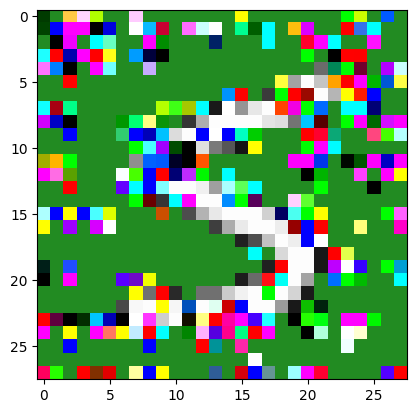

Imagen guardada en: ..\data\MNIST\challenge\edited\0_label5.png
tensor([[-1.2842,  0.5896, -1.3098,  0.5048, -1.4988,  0.6851, -0.9468, -0.6095,
         -0.7274, -1.0898]], device='cuda:0')
Output 5


In [24]:

plt.imshow(to_pil(img))
plt.show()

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(img).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

edited_img = Image.open(edited_dir / (img_file.name))
# Convert the edited image to RGB if it's not
if edited_img.mode != 'RGB':
    edited_img = edited_img.convert('RGB')

# Check prediction
img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model_grad(img_tensor)

print(output)
print("Output", output.argmax(dim=1).item())

Compruebo que no haya cambiado más del 40% de los píxeles y que siga clasificando bien

Píxeles cambiados: 307/784 (39.2%)
Límite permitido: 313/784 (40.0%)
No es necesario aplicar restricción de esparsidad
Porcentaje REAL de píxeles cambiados (verificado): 39.16%
tensor([[-1.2834,  0.5987, -1.3132,  0.5135, -1.5020,  0.6911, -0.9490, -0.6000,
         -0.7290, -1.0804]], device='cuda:0')
Output 5
Imagen guardada en: ..\data\MNIST\challenge\edited\0_label5.png


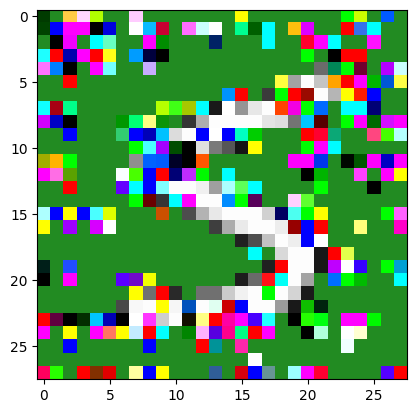

In [25]:
img_file = image_files[0]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

result = apply_sparsity_constraint(original_image=image.to(device), modified_image=img.unsqueeze(0).to(device), method="random")

with torch.no_grad():
    output = model_grad(result.to(device))

print(output)
print("Output", output.argmax(dim=1).item())

plt.imshow(to_pil(result.squeeze(0)))

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(result.squeeze(0)).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")


## Image 2

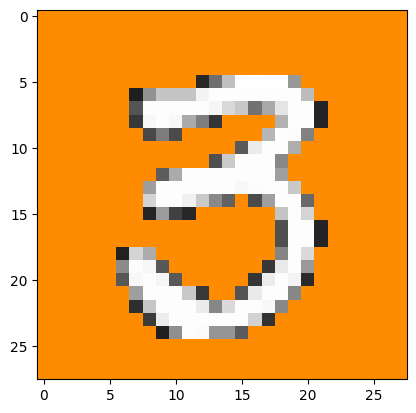

In [26]:
img_file = image_files[1]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.show()

### Explicabilidad

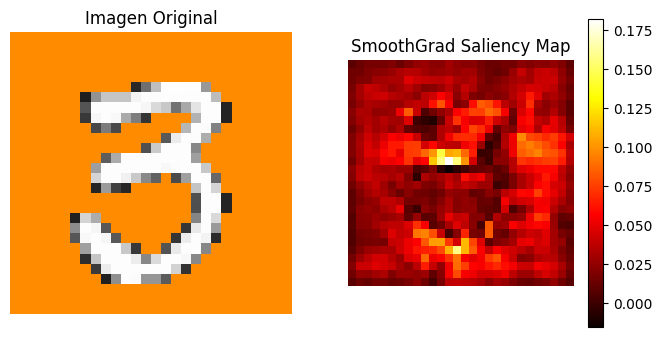

In [27]:
from src.saliency_maps import SmoothGradSaliencyMap

smoothgrad = SmoothGradSaliencyMap()

noise_level = 0.4
sample_size = 200      

model_saliency = deepcopy(model)
model_saliency.eval()


saliency = smoothgrad.explain(
    inputs=image.to(next(model_saliency.parameters()).device),
    model=model_saliency,
    noise_level=noise_level,
    sample_size=sample_size
)


plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().permute(1, 2, 0).cpu())
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency.cpu().detach().numpy().squeeze(), cmap='hot')
plt.title("SmoothGrad Saliency Map")
plt.axis('off')
plt.colorbar()
plt.show()

mask, threshold = extract_top_saliency_pixels(saliency, top_ratio=0.4)

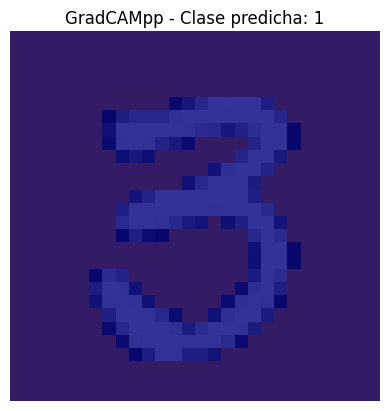

In [28]:

torch.manual_seed(0)

model_cam = deepcopy(model)
model_cam.eval()
cam_extractor = SmoothGradCAMpp(model_cam, target_layer="conv1")

# Forward pass
output = model_cam(image)
pred_class = output.argmax(dim=1).item()

# Extrae Grad-CAM para la clase predicha
activation_map = cam_extractor(5, output)

# Convertir la imagen y el mapa
result = overlay_mask(
    to_pil(image.squeeze().cpu()),
    to_pil_image(activation_map[0], mode='F'),
    alpha=0.2
)

plt.imshow(result)
plt.title(f"GradCAMpp - Clase predicha: {pred_class}")
plt.axis('off')
plt.show()


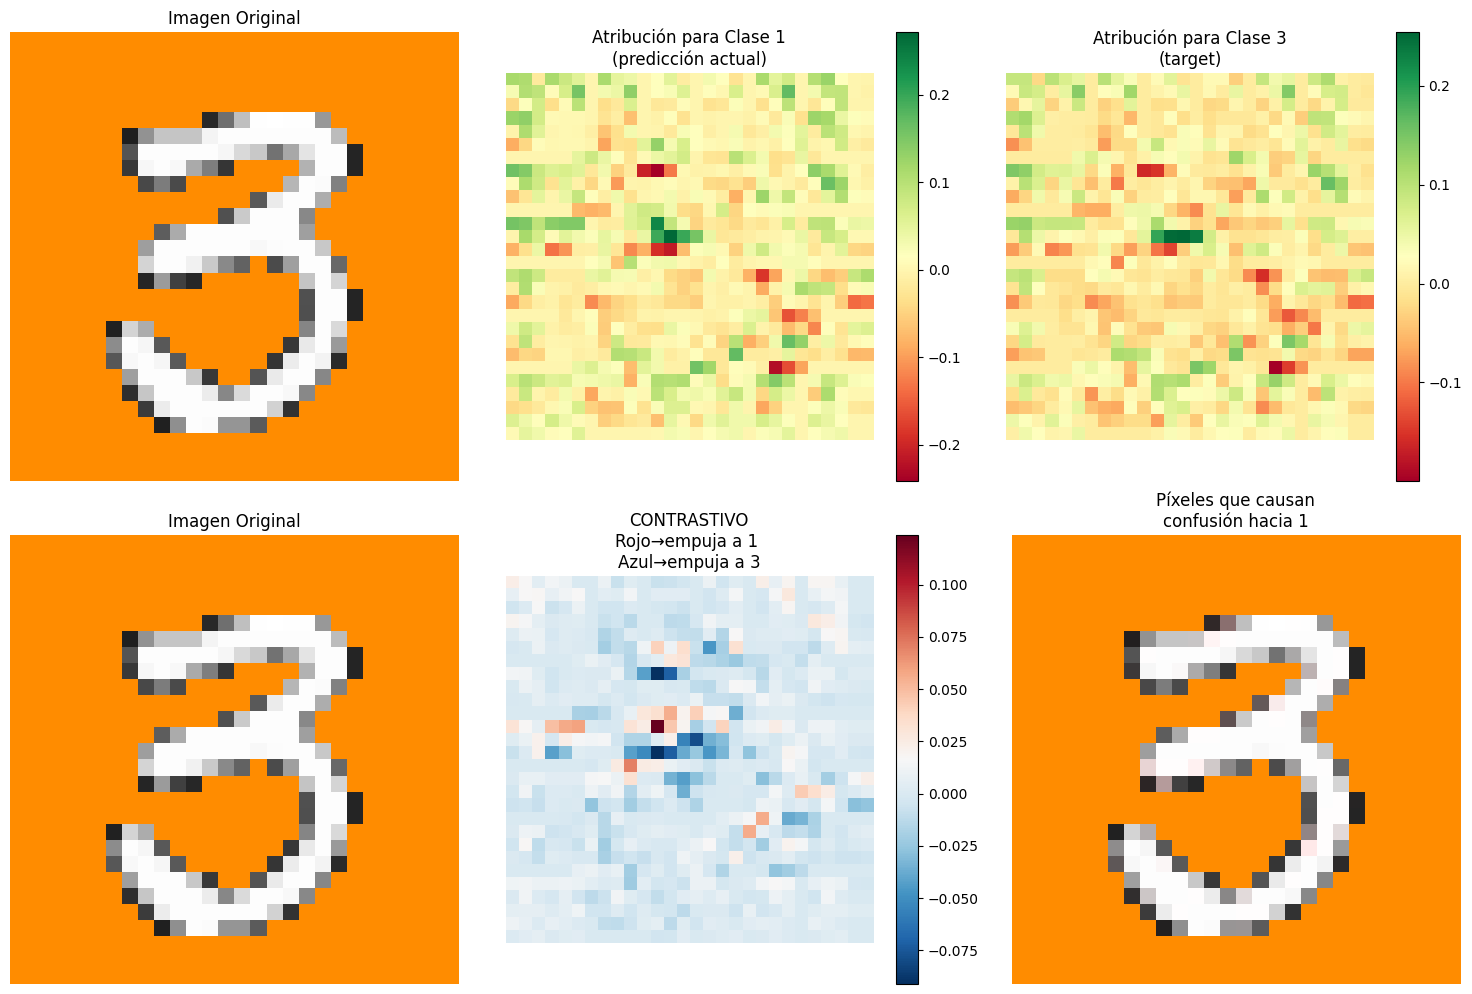

Píxeles problemáticos: 305 de 784 (38.9%)


In [29]:
model_integrated = deepcopy(model)
model_integrated.eval()
attr_pred, attr_true, contrastive, problematic_pixels = explain_and_visualize_integrated_gradients(image, model_integrated, device, true_label=3, predicted_label=1, threshold=34)

In [30]:
from src.gradient_ascent import GradientAscent

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

model_grad = deepcopy(model)
model_grad.eval()

img_file = image_files[1]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
image_grad = deepcopy(image)
grad_asc = GradientAscent(model_grad, iterations=1000, image=image_grad.squeeze(0))

img = grad_asc.explain(target_class=3, init_image=True, sigma=0.3, mask=problematic_pixels)

with torch.no_grad():
    output = model_grad(img.unsqueeze(0).to(device))

print(output)
print("Output", output.argmax(dim=1).item())

  9%|▉         | 89/1000 [00:00<00:01, 885.02it/s]

Epoch 1: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 11: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 21: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 31: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 41: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 51: Pred: 1, Target: 3, Loss: -1.5949, Prob: 0.2588, Top3: [1, 3, 5]
Epoch 61: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 71: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 81: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 91: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 101: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 111: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 121: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 131: Pred: 1, Tar

 27%|██▋       | 270/1000 [00:00<00:00, 895.28it/s]


Epoch 181: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 191: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 201: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 211: Pred: 1, Target: 3, Loss: -1.4939, Prob: 0.2544, Top3: [1, 3, 5]
Epoch 221: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 231: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 241: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 251: Pred: 3, Target: 3, Loss: -1.1865, Prob: 0.2313, Top3: [3, 5, 1]
Epoch 261: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 271: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 281: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 291: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 301: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 311: 

 46%|████▋     | 463/1000 [00:00<00:00, 930.16it/s]

...

Epoch 561: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 571: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 581: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 591: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 601: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 611: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 621: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 631: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 641: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 651: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 661: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 671: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 681: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 691: P

 84%|████████▍ | 839/1000 [00:00<00:00, 900.13it/s]

Epoch 751: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 761: Pred: 1, Target: 3, Loss: -1.4409, Prob: 0.2515, Top3: [1, 3, 5]
Epoch 771: Pred: 3, Target: 3, Loss: -1.4034, Prob: 0.2491, Top3: [3, 1, 5]
Epoch 781: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 791: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 801: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 811: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 821: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 831: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 841: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 851: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 861: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 871: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 881: P

100%|██████████| 1000/1000 [00:01<00:00, 898.51it/s]

Epoch 921: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 931: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 941: Pred: 3, Target: 3, Loss: -1.2907, Prob: 0.2407, Top3: [3, 1, 5]
Epoch 951: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 961: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 971: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 981: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 991: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
Epoch 1000: Pred: 1, Target: 3, Loss: -1.5981, Prob: 0.2589, Top3: [1, 3, 5]
tensor([[-1.1748,  1.7353, -1.7385,  1.5981, -1.9058,  1.4470, -1.2319,  0.5896,
         -0.9340,  0.1008]], device='cuda:0')
Output 1


### Cambios

Analizando 1010 imágenes de clase 3...

Mejor ejemplar encontrado: 07326_idx7326_label3.png
Confianza: 0.3235


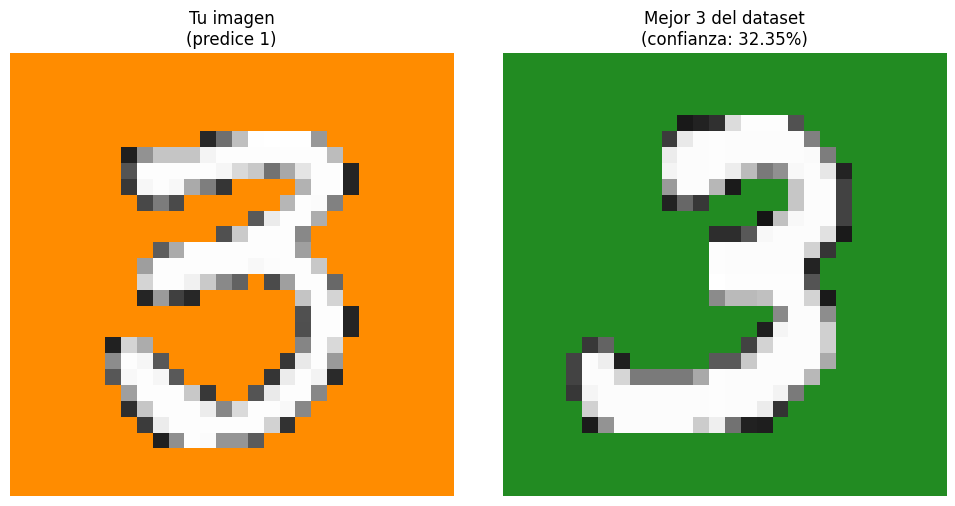

In [31]:
# Buscar mejor 5
best_3, best_3_path, score_3 = find_best_prototype(model, device, target_class=3)

# Comparar con tu imagen
your_image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(to_pil(your_image.squeeze().cpu()))
axes[0].set_title(f"Tu imagen\n(predice 1)")
axes[0].axis('off')

axes[1].imshow(to_pil(best_3.squeeze().cpu()))
axes[1].set_title(f"Mejor 3 del dataset\n(confianza: {score_3:.2%})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

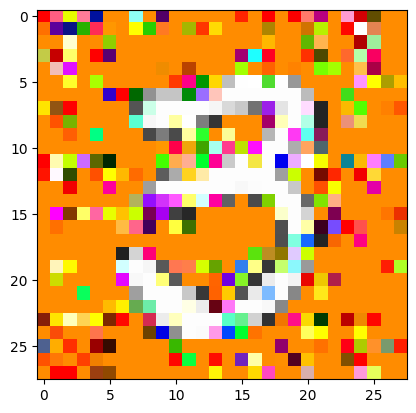

Imagen guardada en: ..\data\MNIST\challenge\edited\1_label3.png
tensor([[-1.1748,  1.7353, -1.7385,  1.5981, -1.9058,  1.4470, -1.2319,  0.5896,
         -0.9340,  0.1008]], device='cuda:0')
Output 1


In [32]:
plt.imshow(to_pil(img))
plt.show()

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(img).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

edited_img = Image.open(edited_dir / (img_file.name))
# Convert the edited image to RGB if it's not
if edited_img.mode != 'RGB':
    edited_img = edited_img.convert('RGB')

# Check prediction
img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model_grad(img_tensor)

print(output)
print("Output", output.argmax(dim=1).item())

El output sigue sin ser la clase correcta. Por tanto, pruebo otro método

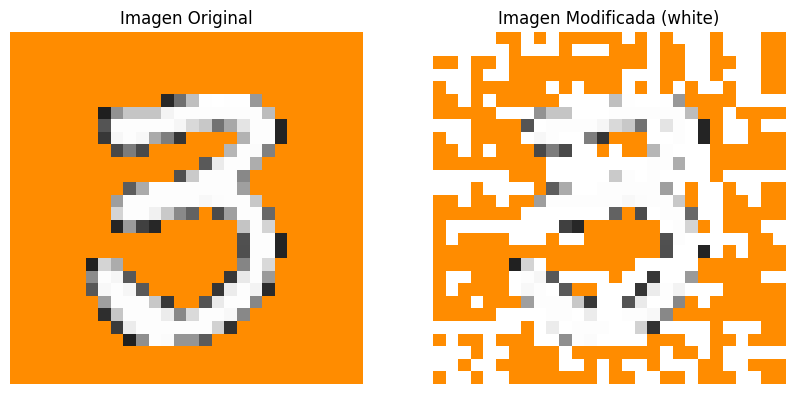

Imagen guardada en: ..\data\MNIST\challenge\edited\1_label3.png
tensor([[-1.7004,  0.9047, -2.1291,  1.1112, -1.6906,  1.0594, -1.0042,  0.8755,
         -1.0781,  0.4713]], device='cuda:0')
Output 3
Imagen guardada en: ..\data\MNIST\challenge\edited\1_label3.png


In [33]:
# img = modify_image_with_bool_mask(image, mask.squeeze(0).squeeze(0).cpu().detach().numpy(), img_file, mode="white")
img_file = image_files[1]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

img = modify_image_with_bool_mask(image, problematic_pixels, img_file, mode="white")

img_tensor = img.to(device)
with torch.no_grad():
    output = model_grad(img_tensor)

print(output)
print("Output", output.argmax(dim=1).item())

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(img.squeeze(0)).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

## Imagen 3

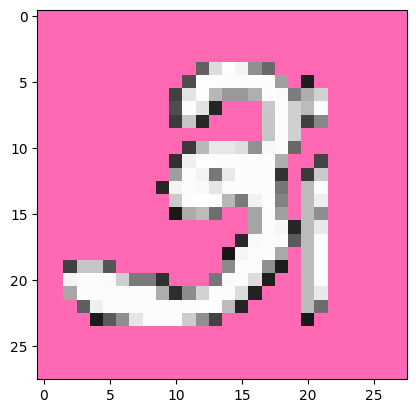

In [34]:
img_file = image_files[2]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.show()

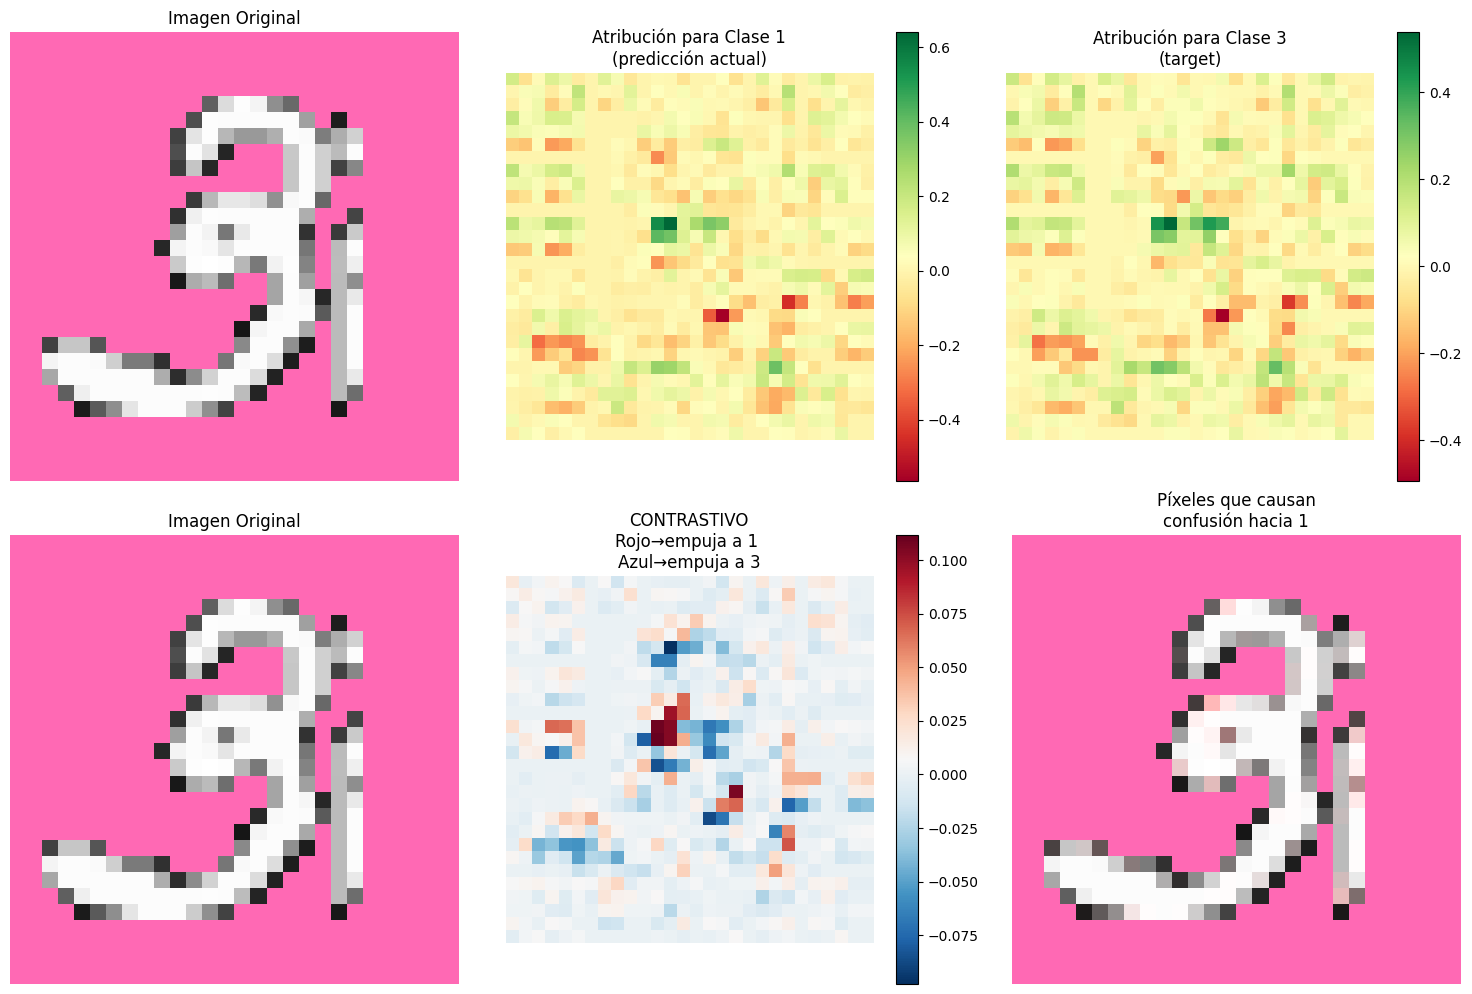

Píxeles problemáticos: 296 de 784 (37.8%)


In [35]:
model_integrated = deepcopy(model)
model_integrated.eval()
attr_pred, attr_true, contrastive, problematic_pixels = explain_and_visualize_integrated_gradients(image, model_integrated, device, true_label=3, predicted_label=1, threshold=35)

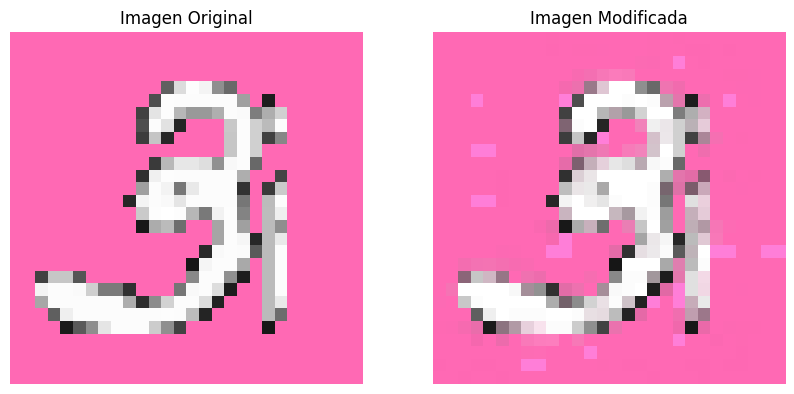

2_label3.png
..\data\MNIST\challenge\edited\2_label3.png
Imagen guardada en: ..\data\MNIST\challenge\edited\2_label3.png


In [36]:
img = modify_image_based_on_mask(image, contrastive, img_file)

Esta clasificación sigue sin ser correcta. Vuelvo a probar el gradient ascent con máscara

In [37]:
from src.gradient_ascent import GradientAscent

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

model_grad = deepcopy(model)
model_grad.eval()

img_file = image_files[2]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
image_grad = deepcopy(image)
grad_asc = GradientAscent(model_grad, iterations=100, image=image_grad.squeeze(0))

img = grad_asc.explain(target_class=3, init_image=True, sigma=0.1, mask=problematic_pixels)

with torch.no_grad():
    output = model_grad(img.unsqueeze(0).to(device))

print(output)
print("Output", output.argmax(dim=1).item())

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: Pred: 6, Target: 3, Loss: 3.3514, Prob: 0.0079, Top3: [6, 2, 8]
Epoch 11: Pred: 5, Target: 3, Loss: 0.0505, Prob: 0.1685, Top3: [5, 1, 3]
Epoch 21: Pred: 5, Target: 3, Loss: 0.1855, Prob: 0.1579, Top3: [5, 1, 3]
Epoch 31: Pred: 8, Target: 3, Loss: 1.1476, Prob: 0.0829, Top3: [8, 5, 6]
Epoch 41: Pred: 5, Target: 3, Loss: 0.7667, Prob: 0.1112, Top3: [5, 8, 6]


100%|██████████| 100/100 [00:00<00:00, 884.30it/s]

Epoch 51: Pred: 2, Target: 3, Loss: 2.3977, Prob: 0.0236, Top3: [2, 8, 6]
Epoch 61: Pred: 5, Target: 3, Loss: -0.1561, Prob: 0.1841, Top3: [5, 1, 3]
Epoch 71: Pred: 8, Target: 3, Loss: 1.9637, Prob: 0.0381, Top3: [8, 6, 2]
Epoch 81: Pred: 5, Target: 3, Loss: 0.6309, Prob: 0.1219, Top3: [5, 8, 1]
Epoch 91: Pred: 1, Target: 3, Loss: -1.1891, Prob: 0.2440, Top3: [1, 3, 5]
Epoch 100: Pred: 1, Target: 3, Loss: -1.0380, Prob: 0.2373, Top3: [1, 5, 3]
tensor([[-1.1748,  1.7353, -1.7385,  1.5981, -1.9058,  1.4470, -1.2319,  0.5896,
         -0.9340,  0.1008]], device='cuda:0')
Output 1


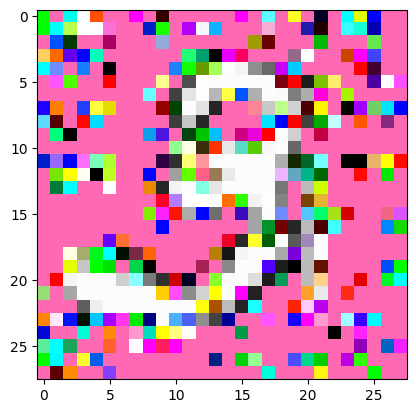

Imagen guardada en: ..\data\MNIST\challenge\edited\2_label3.png
tensor([[-1.1748,  1.7353, -1.7385,  1.5981, -1.9058,  1.4470, -1.2319,  0.5896,
         -0.9340,  0.1008]], device='cuda:0')
Output 1
Píxeles cambiados: 296/784 (37.8%)
Límite permitido: 313/784 (40.0%)
No es necesario aplicar restricción de esparsidad
Porcentaje REAL de píxeles cambiados (verificado): 37.76%
tensor([[-1.1748,  1.7353, -1.7385,  1.5981, -1.9058,  1.4470, -1.2319,  0.5896,
         -0.9340,  0.1008]], device='cuda:0')
Output 1
Imagen guardada en: ..\data\MNIST\challenge\edited\2_label3.png


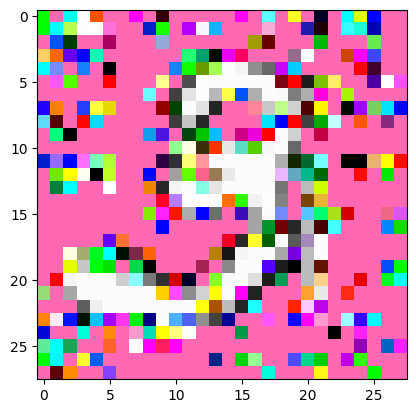

In [38]:
plt.imshow(to_pil(img))
plt.show()

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(img).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

edited_img = Image.open(edited_dir / (img_file.name))
# Convert the edited image to RGB if it's not
if edited_img.mode != 'RGB':
    edited_img = edited_img.convert('RGB')

# Check prediction
img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
with torch.no_grad():
    output = model_grad(img_tensor)

print(output)
print("Output", output.argmax(dim=1).item())

img_file = image_files[2]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

result = apply_sparsity_constraint(original_image=image.to(device), modified_image=img.unsqueeze(0).to(device), method="random")

with torch.no_grad():
    output = model_grad(result.to(device))

print(output)
print("Output", output.argmax(dim=1).item())

plt.imshow(to_pil(result.squeeze(0)))

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(result.squeeze(0)).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")


El output sigue sin ser el esperado, por lo que vuelvo a usar otras técnicas (mapa de saliencia) para intentar modificar esos píxeles

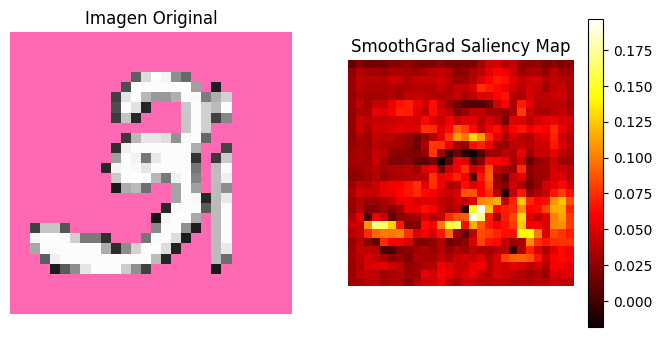

In [39]:
from src.saliency_maps import SmoothGradSaliencyMap

img_file = image_files[2]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

smoothgrad = SmoothGradSaliencyMap()

noise_level = 0.4
sample_size = 200      

model_saliency = deepcopy(model)
model_saliency.eval()


saliency = smoothgrad.explain(
    inputs=image.to(next(model_saliency.parameters()).device),
    model=model_saliency,
    noise_level=noise_level,
    sample_size=sample_size
)


plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze().permute(1, 2, 0).cpu())
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(saliency.cpu().detach().numpy().squeeze(), cmap='hot')
plt.title("SmoothGrad Saliency Map")
plt.axis('off')
plt.colorbar()
plt.show()

mask, threshold = extract_top_saliency_pixels(saliency, top_ratio=0.1)

No funcionó con la máscara del saliency_map, pero sí usando los píxeles problemáticos identificados con Integrated Gradients

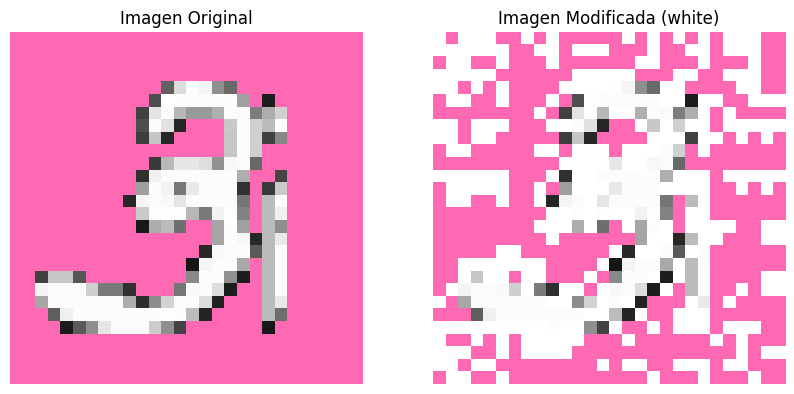

Imagen guardada en: ..\data\MNIST\challenge\edited\2_label3.png
tensor([[-1.4717,  1.2661, -1.9591,  1.3231, -1.7843,  1.2281, -1.1033,  0.7511,
         -1.0154,  0.3101]], device='cuda:0')
Output 3
Imagen guardada en: ..\data\MNIST\challenge\edited\2_label3.png


In [40]:
# img = modify_image_with_bool_mask(image, mask.squeeze(0).squeeze(0).cpu().detach().numpy(), img_file, mode="white")
img_file = image_files[2]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)

img = modify_image_with_bool_mask(image, problematic_pixels, img_file, mode="white")

img_tensor = img.to(device)
with torch.no_grad():
    output = model_grad(img_tensor)

print(output)
print("Output", output.argmax(dim=1).item())

edited_dir = challenge_dir / 'edited'
edited_dir.mkdir(parents=True, exist_ok=True)
to_pil(img.squeeze(0)).save(edited_dir / img_file.name)
print(f"Imagen guardada en: {edited_dir / (img_file.name)}")

## Imagen 4

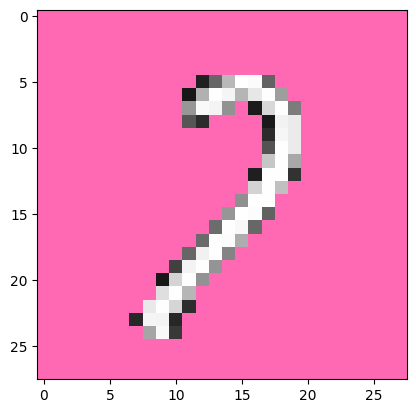

In [41]:
img_file = image_files[3]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.show()

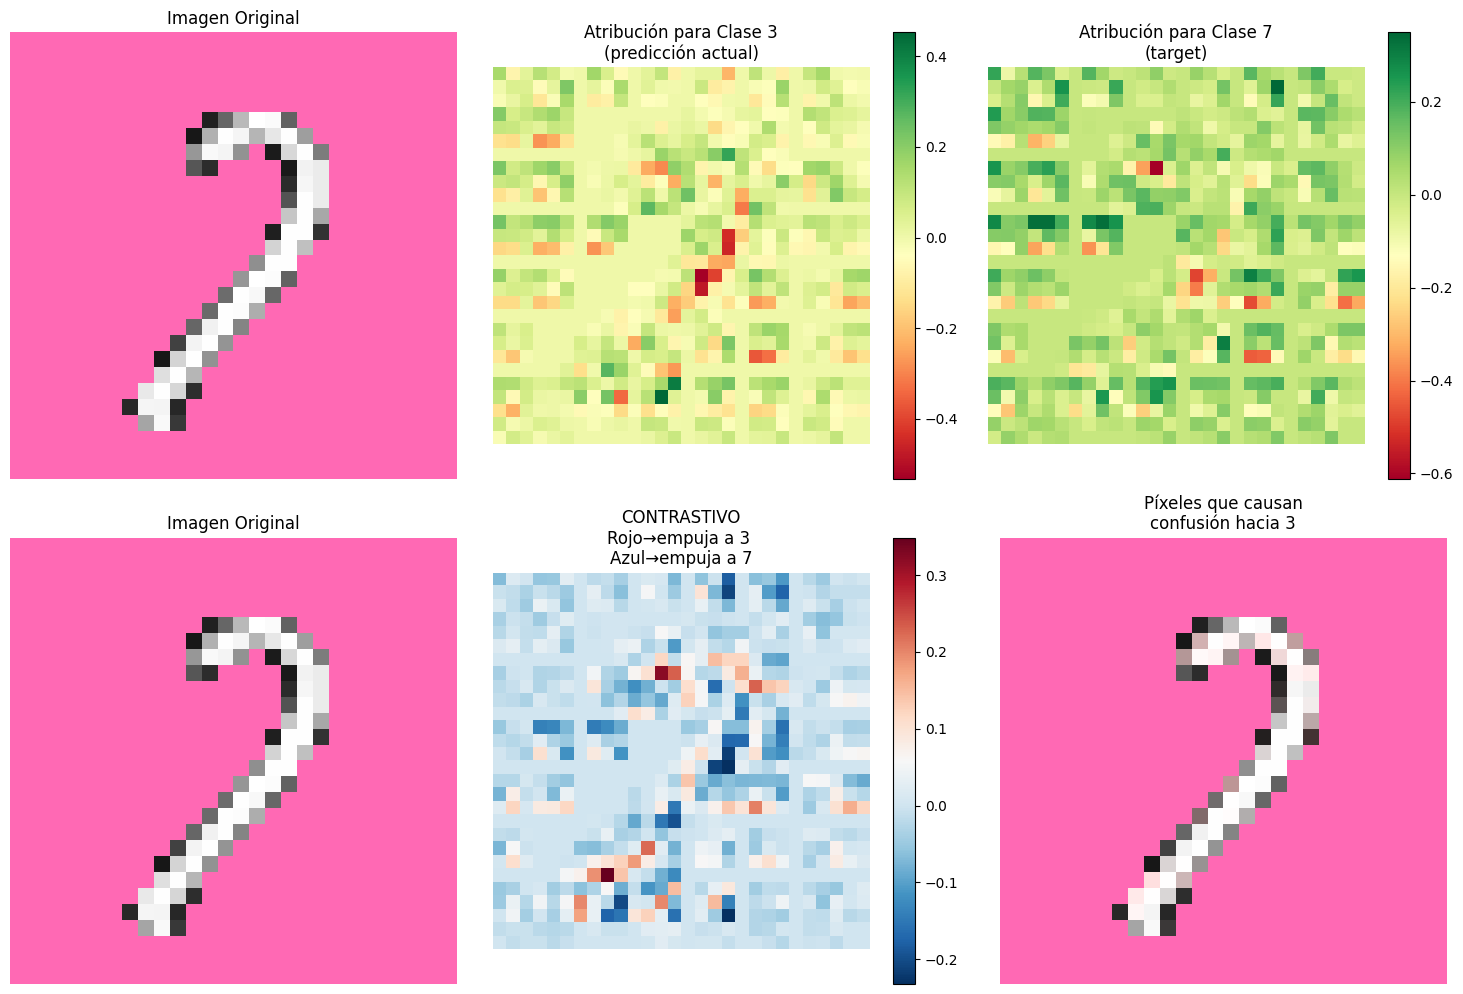

Píxeles problemáticos: 142 de 784 (18.1%)


In [42]:
model_integrated = deepcopy(model)
model_integrated.eval()
attr_pred, attr_true, contrastive, problematic_pixels = explain_and_visualize_integrated_gradients(image, model_integrated, device, true_label=7, predicted_label=3)

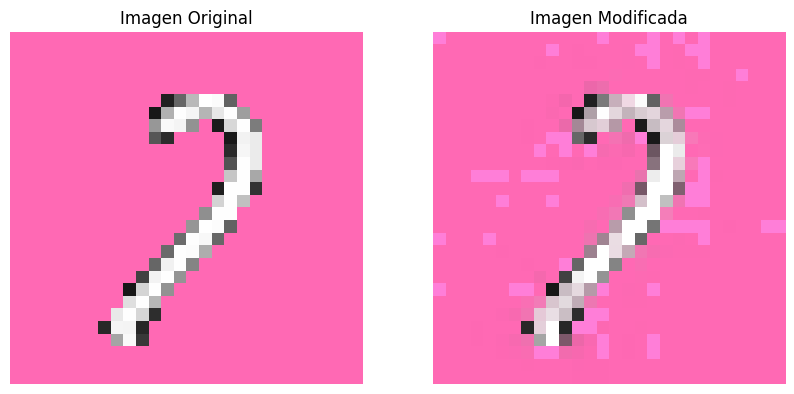

3_label7.png
..\data\MNIST\challenge\edited\3_label7.png
Imagen guardada en: ..\data\MNIST\challenge\edited\3_label7.png


In [43]:
img = modify_image_based_on_mask(image, contrastive, img_file)

Con esto ya clasifica la clase correcta

## Imagen 5

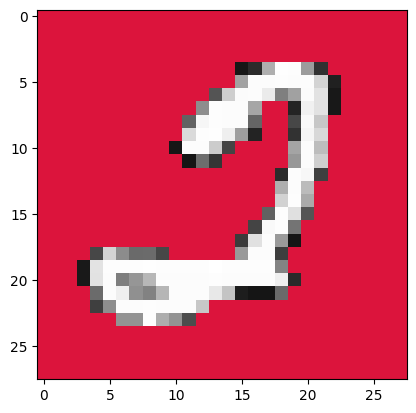

In [44]:
img_file = image_files[-1]
image = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
plt.imshow(to_pil(image.squeeze().cpu()))
plt.show()

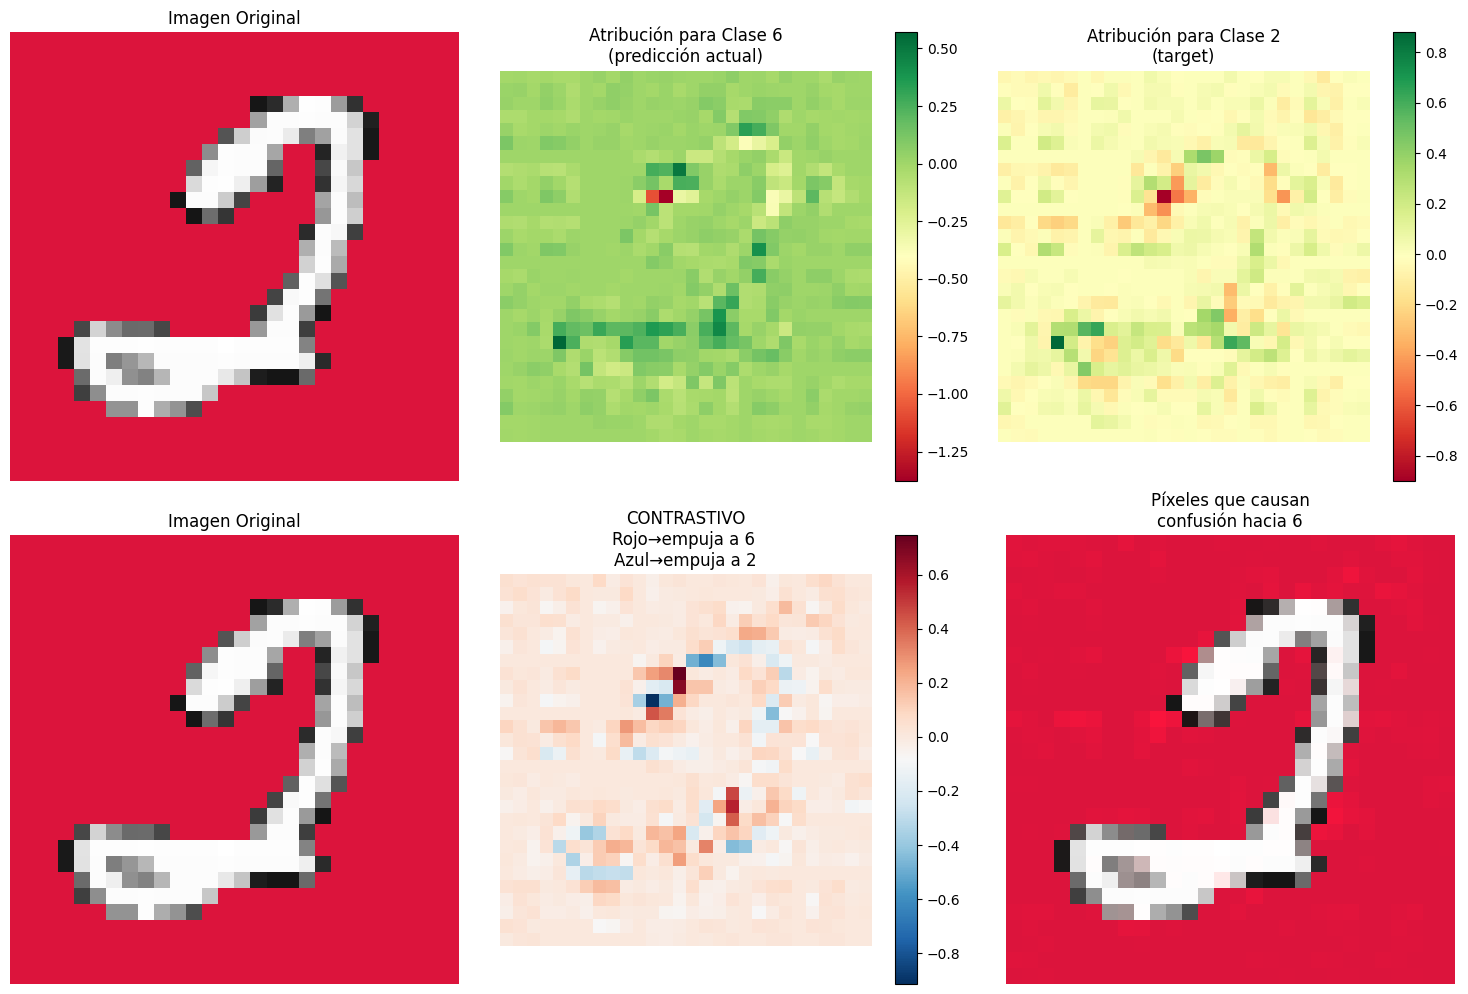

Píxeles problemáticos: 86 de 784 (11.0%)


In [45]:
model_integrated = deepcopy(model)
model_integrated.eval()

attr_pred, attr_true, contrastive, problematic_pixels = explain_and_visualize_integrated_gradients(image, model_integrated, device, true_label=2, predicted_label=6, threshold=80)

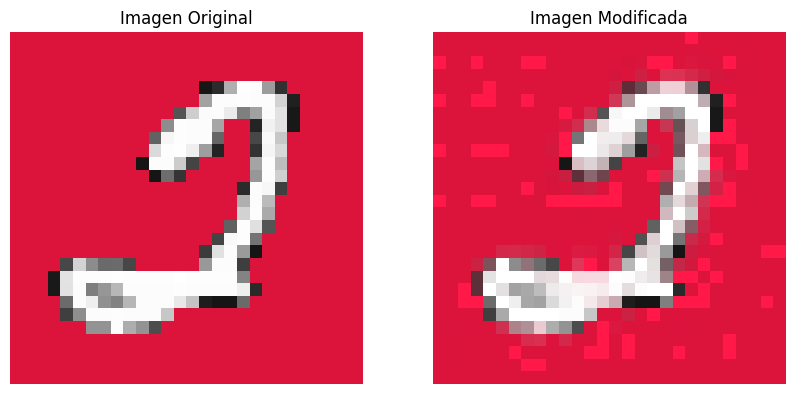

4_label2.png
..\data\MNIST\challenge\edited\4_label2.png
Imagen guardada en: ..\data\MNIST\challenge\edited\4_label2.png


In [46]:
img = modify_image_based_on_mask(image, contrastive, img_file, incorrect_threshold=70, correct_threshold=15)

Sigue sin clasificar la clase correcta, por lo que pruebo otros métodos

Analizando 1032 imágenes de clase 2...

Mejor ejemplar encontrado: 08550_idx8550_label2.png
Confianza: 0.9994


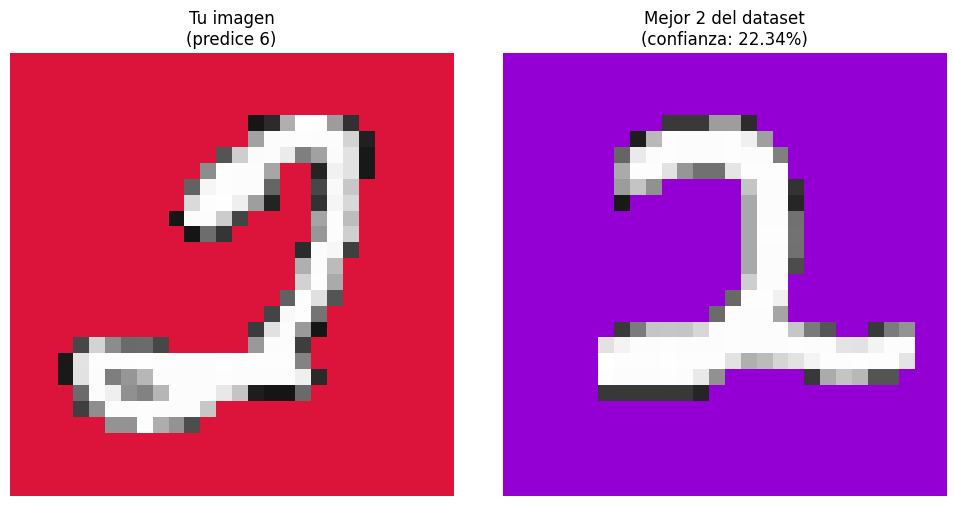

In [47]:
best_image, best_path, best_score = find_best_prototype(model, device, target_class=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(to_pil(image.squeeze().cpu()))
axes[0].set_title(f"Tu imagen\n(predice 6)")
axes[0].axis('off')

axes[1].imshow(to_pil(best_image.squeeze().cpu()))
axes[1].set_title(f"Mejor 2 del dataset\n(confianza: {score_5:.2%})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Vistos los doses que clasifica bien del dataset, parece que no clasifica bien por el "agujero" que hay en la parte inferior, por lo que lo cubro con un cuadrado.

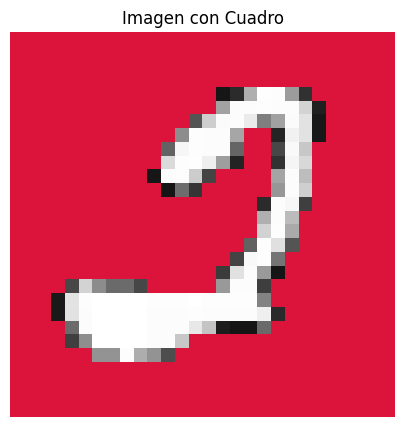

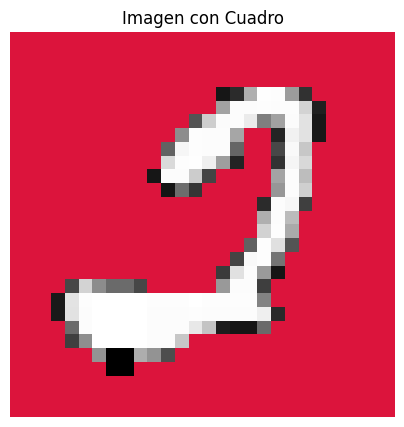

In [48]:
img = plot_square(19, 6, 4, 4, image, "white")
img = plot_square(23, 7, 2, 2, img, "black")
to_pil(img).save(challenge_dir / 'edited' / img_file.name)


---
## Check if you have passed the challenge 

In [49]:
# Check percentage of editing an image
def calculate_edit_percentage(original_img, edited_img):
    original_pixels = original_img.load()
    edited_pixels = edited_img.load()
    width, height = original_img.size
    total_pixels = width * height
    changed_pixels = 0

    for x in range(width):
        for y in range(height):
            if original_pixels[x, y] != edited_pixels[x, y]:
                changed_pixels += 1

    return (changed_pixels / total_pixels) * 100

In [50]:
models_dir = Path('../models')
model_name = models_dir / 'small_cnn.pth'
model = torch.load(model_name, weights_only=False)
model.to(device) 
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=588, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=10, bias=True)
)

In [ ]:
# Create edited directory
edited_dir = challenge_dir / 'edited'

# Load edited images, check that they are predicted correctly and calculate edit percentages
for original_img_file, edited_img_file in zip(challenge_dir.glob('*.png'), edited_dir.glob('*.png')):
    original_img = Image.open(original_img_file)
    edited_img = Image.open(edited_img_file)
    # Convert the edited image to RGB if it's not
    if edited_img.mode != 'RGB':
        edited_img = edited_img.convert('RGB')

    # Check prediction
    img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).item()
    
    print(f'Edited {edited_img_file.name}: Pred: {pred}, Label: {original_img_file.stem[-1]}, correct: {pred == int(original_img_file.stem[-1])}')

    # Calculate edit percentage
    edit_percentage = calculate_edit_percentage(original_img, edited_img)
    print(f'Edit Percentage: {edit_percentage:.2f}%')


Edited 0_label5.png: Pred: 5, Label: 5, correct: True
Edit Percentage: 39.16%
Edited 1_label3.png: Pred: 3, Label: 3, correct: True
Edit Percentage: 38.90%
Edited 2_label3.png: Pred: 3, Label: 3, correct: True
Edit Percentage: 37.76%
Edited 3_label7.png: Pred: 7, Label: 7, correct: True
Edit Percentage: 28.06%
Edited 4_label2.png: Pred: 2, Label: 2, correct: True
Edit Percentage: 2.55%
